In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("upi_transactions_2024.csv")

print("Head Method\n",df.head())
print("Shape\n",df.shape)
print("column\n",df.columns)
print("Info Method\n",df.info())
print("Describe Method\n",df.describe())
print("Is Any NUll \n",df.isnull().sum())



Head Method
   transaction id            timestamp transaction type merchant_category  \
0  TXN0000000001  2024-10-08 15:17:28              P2P     Entertainment   
1  TXN0000000002  2024-04-11 06:56:00              P2M           Grocery   
2  TXN0000000003  2024-04-02 13:27:18              P2P           Grocery   
3  TXN0000000004  2024-01-07 10:09:17              P2P              Fuel   
4  TXN0000000005  2024-01-23 19:04:23              P2P          Shopping   

   amount (INR) transaction_status sender_age_group receiver_age_group  \
0           868            SUCCESS            26-35              18-25   
1          1011            SUCCESS            26-35              26-35   
2           477            SUCCESS            26-35              36-45   
3          2784            SUCCESS            26-35              26-35   
4           990            SUCCESS            26-35              18-25   

    sender_state sender_bank receiver_bank device_type network_type  \
0          Del

In [15]:
print(df["fraud_flag"].value_counts())
status_counts = df["transaction_status"].value_counts()
print(status_counts)
status_percentage = df["transaction_status"].value_counts(normalize=True) * 100

print(status_percentage)


fraud_flag
0    249520
1       480
Name: count, dtype: int64
transaction_status
SUCCESS    237624
FAILED      12376
Name: count, dtype: int64
transaction_status
SUCCESS    95.0496
FAILED      4.9504
Name: proportion, dtype: float64


In [16]:
total_value = df["amount (INR)"].sum()
average_value = df["amount (INR)"].mean()
median_value = df["amount (INR)"].median()
maximum_value = df["amount (INR)"].max()

print(f"Total Transaction Value: ₹{total_value:,.2f}")
print(f"Average Transaction: ₹{average_value:,.2f}")
print(f"Median Transaction: ₹{median_value:,.2f}")
print(f"Maximum Transaction: ₹{maximum_value:,.2f}")


Total Transaction Value: ₹327,939,009.00
Average Transaction: ₹1,311.76
Median Transaction: ₹629.00
Maximum Transaction: ₹42,099.00


In [60]:
merchant_analysis = df.groupby("merchant_category").agg(
    transaction_count=("transaction id", "count"),
    total_value=("amount (INR)", "sum"),
    average_amount=("amount (INR)", "mean")
).sort_values("total_value", ascending=False)

print(merchant_analysis)

top_merchants = merchant_analysis.head(5)

print(top_merchants)

                   transaction_count  total_value  average_amount
merchant_category                                                
Shopping                       29872     76863207     2573.085398
Grocery                        49966     58277893     1166.350979
Utilities                      22338     52742482     2361.110305
Fuel                           25063     38982575     1555.383434
Education                       7598     38704346     5094.017636
Other                          24828     21073449      848.777550
Food                           37464     19919402      531.694480
Entertainment                  20103      8309080      413.325374
Healthcare                     12663      6874159      542.853905
Transport                      20105      6192416      308.003780
                   transaction_count  total_value  average_amount
merchant_category                                                
Shopping                       29872     76863207     2573.085398
Grocery   

In [63]:
hour_analysis=df.groupby('hour_of_day').agg(
    transaction_count=("transaction id", "count"),
    total_value=('amount (INR)',"sum"),
    average_amount=('amount (INR)',"mean")
)

print(hour_analysis)

busy_hour=hour_analysis.sort_values("total_value", ascending=False)

print(busy_hour.head(5))

             transaction_count  total_value  average_amount
hour_of_day                                                
0                         3388      4532884     1337.923259
1                         2244      2914350     1298.729947
2                         1685      2173750     1290.059347
3                         1314      1678669     1277.525875
4                         1247      1670700     1339.775461
5                         1742      2134122     1225.098737
6                         3501      4617034     1318.775778
7                         5630      7482766     1329.088099
8                         8349     10979614     1315.081327
9                        10450     13809021     1321.437416
10                       13904     18337313     1318.851625
11                       16328     21193161     1297.964294
12                       17516     23406280     1336.279973
13                       15038     19847819     1319.844328
14                       11472     14848

In [ ]:
day_analysis=df.groupby("day_of_week").agg(
    transaction_count=("transaction id","count"),
    total_value=("amount (INR)","sum"),
    average_amount=("amount (INR)","mean")
).sort_values('day_of_week')

day_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_analysis=day_analysis.reindex(day_order)
print(day_analysis)


In [ ]:
weekend_analysis = df.groupby("is_weekend").agg(
    transaction_count=("transaction id", "count"),
    total_value=("amount (INR)", "sum"),
    average_amount=("amount (INR)", "mean")
)

print(weekend_analysis)

In [20]:
age_analysis = df.groupby("sender_age_group").agg(
    transaction_count=("transaction id", "count"),
    total_value=("amount (INR)", "sum"),
    average_amount=("amount (INR)", "mean")
)

print(age_analysis)

                  transaction_count  total_value  average_amount
sender_age_group                                                
18-25                         62345     74473936     1194.545449
26-35                         87432    115959771     1326.285239
36-45                         62873     89533745     1424.041242
46-55                         24841     33116261     1333.129141
56+                           12509     14855296     1187.568631


In [21]:
state_analysis = df.groupby("sender_state").agg(
    transaction_count=("transaction id", "count"),
    total_value=("amount (INR)", "sum"),
    average_amount=("amount (INR)", "mean")
).sort_values("transaction_count", ascending=False)

print(state_analysis.head(10))

                transaction_count  total_value  average_amount
sender_state                                                  
Maharashtra                 37427     49043948     1310.389505
Uttar Pradesh               30125     40035717     1328.986456
Karnataka                   29756     38451158     1292.215284
Tamil Nadu                  25367     33343518     1314.444672
Delhi                       24870     32689865     1314.429634
Telangana                   22435     29750930     1326.094495
Gujarat                     20061     25988190     1295.458352
Andhra Pradesh              20006     25952619     1297.241777
Rajasthan                   19981     26730470     1337.794405
West Bengal                 19972     25952594     1299.448928


In [29]:
fraud_analysis=df.groupby('fraud_flag').agg(
     transaction_count=("transaction id", "count"),
    total_value=("amount (INR)", "sum"),
    average_amount=("amount (INR)", "mean")
)

print(fraud_analysis)

fraud_by_hour = df.groupby("hour_of_day").agg(
    fraud_count=("fraud_flag", "sum"),
    total_transactions=("transaction id", "count")
)

print(fraud_by_hour)

print(fraud_by_hour.sort_values("fraud_count", ascending=False).head(5))

            transaction_count  total_value  average_amount
fraud_flag                                                
0                      249520    327219378     1311.395391
1                         480       719631     1499.231250
             fraud_count  total_transactions
hour_of_day                                 
0                      8                3388
1                      6                2244
2                      3                1685
3                      4                1314
4                      1                1247
5                      1                1742
6                      5                3501
7                     13                5630
8                     18                8349
9                     20               10450
10                    20               13904
11                    27               16328
12                    30               17516
13                    25               15038
14                    21               11472

In [32]:
#Fraud by Transaction Type
fraud_by_type = df.groupby("transaction type").agg(
    fraud_count=("fraud_flag", "sum"),
    total_transactions=("transaction id", "count")
).sort_values("fraud_count", ascending=False)

print(fraud_by_type)

                  fraud_count  total_transactions
transaction type                                 
P2P                       206              112445
P2M                       167               87660
Bill Payment               77               37368
Recharge                   30               12527


In [48]:
#Fraud Analysis by State
fraud_by_state = df.groupby("sender_state").agg(
    fraud_count=("fraud_flag", "sum"),
    total_transactions=("transaction id", "count")
)

fraud_by_state["fraud_rate"] = (
    fraud_by_state["fraud_count"]
    / fraud_by_state["total_transactions"]
    * 100
)

print(fraud_by_state.sort_values("fraud_count", ascending=False).head(10))

                fraud_count  total_transactions  fraud_rate
sender_state                                               
Maharashtra              71               37427    0.189703
Karnataka                69               29756    0.231886
Uttar Pradesh            52               30125    0.172614
Delhi                    50               24870    0.201045
Rajasthan                46               19981    0.230219
Gujarat                  43               20061    0.214346
Tamil Nadu               40               25367    0.157685
Telangana                39               22435    0.173836
Andhra Pradesh           35               20006    0.174948
West Bengal              35               19972    0.175245


In [36]:
#Fraud by Merchant Type
print("Fraud_By_Merchant_Types\n")
fraud_by_merchant=df.groupby('merchant_category').agg(
fraud_count=("fraud_flag", "sum"),
    total_transactions=("transaction id", "count")
).sort_values('fraud_count',ascending=False)
print(fraud_by_merchant)

Fraud_By_Merchant_Types

                   fraud_count  total_transactions
merchant_category                                 
Grocery                     94               49966
Food                        73               37464
Shopping                    62               29872
Other                       50               24828
Fuel                        48               25063
Transport                   43               20105
Entertainment               40               20103
Utilities                   33               22338
Healthcare                  21               12663
Education                   16                7598


In [37]:
fraud_by_merchant["fraud_rate"] = (
    fraud_by_merchant["fraud_count"]
    / fraud_by_merchant["total_transactions"]
    * 100
)

print(fraud_by_merchant.sort_values("fraud_rate", ascending=False))

                   fraud_count  total_transactions  fraud_rate
merchant_category                                             
Transport                   43               20105    0.213877
Education                   16                7598    0.210582
Shopping                    62               29872    0.207552
Other                       50               24828    0.201386
Entertainment               40               20103    0.198975
Food                        73               37464    0.194854
Fuel                        48               25063    0.191517
Grocery                     94               49966    0.188128
Healthcare                  21               12663    0.165837
Utilities                   33               22338    0.147730


In [39]:
fraud_by_age = df.groupby("sender_age_group").agg(
    fraud_count=("fraud_flag", "sum"),
    total_transactions=("transaction id", "count")
).sort_values('fraud_count',ascending=False)

fraud_by_age["fraud_rate"] = (
    fraud_by_age["fraud_count"]
    / fraud_by_age["total_transactions"]
    * 100
)

print(fraud_by_age)

                  fraud_count  total_transactions  fraud_rate
sender_age_group                                             
26-35                     163               87432    0.186431
18-25                     143               62345    0.229369
36-45                     116               62873    0.184499
46-55                      31               24841    0.124794
56+                        27               12509    0.215845


In [53]:
#fraud_by_device
fraud_by_device = df.groupby("device_type").agg(
    fraud_count=("fraud_flag", "sum"),
    total_transactions=("transaction id", "count")
).sort_values('fraud_count',ascending=False)

fraud_by_device["fraud_rate"] = (
    fraud_by_device["fraud_count"]
    / fraud_by_device["total_transactions"]
    * 100
)

print(fraud_by_device)

             fraud_count  total_transactions  fraud_rate
device_type                                             
Android              364              187777    0.193847
iOS                   90               49613    0.181404
Web                   26               12610    0.206186


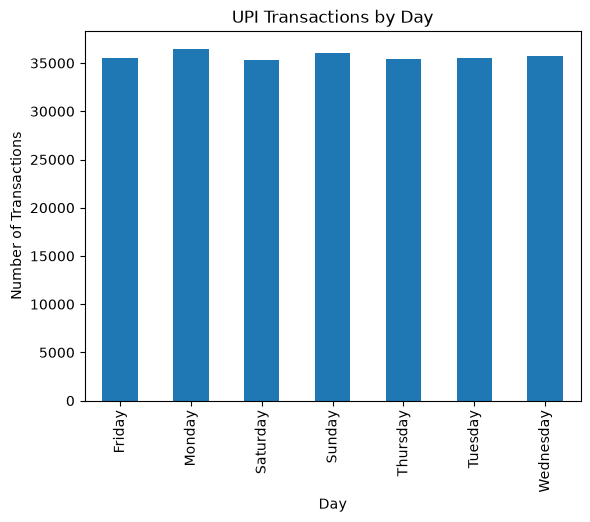

In [47]:

day_analysis["transaction_count"].plot(kind="bar")

plt.title("UPI Transactions by Day")
plt.xlabel("Day")
plt.ylabel("Number of Transactions")

plt.show()

In [ ]:
fraud_by_age['fraud_count']

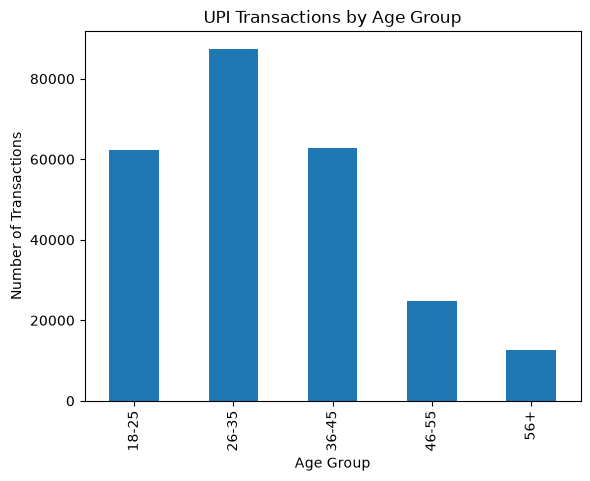

In [58]:
#bar graph dfor transaction by age group
age_analysis["transaction_count"].plot(kind="bar")

plt.title("UPI Transactions by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")

plt.show()

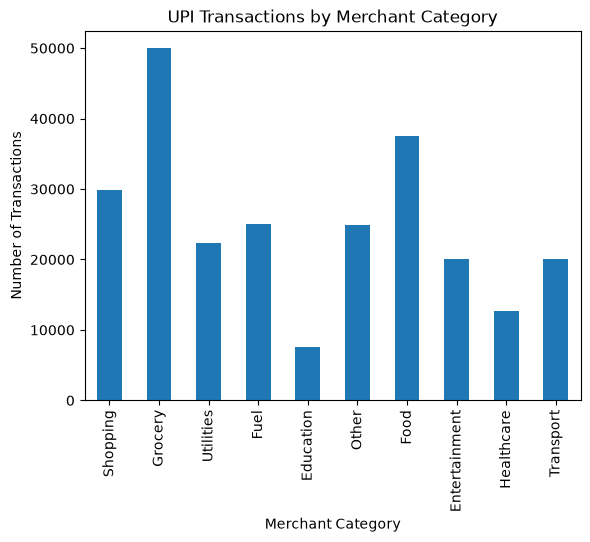

In [61]:
#bar graph for merchant analysis
merchant_analysis["transaction_count"].plot(kind="bar")

plt.title("UPI Transactions by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Number of Transactions")

plt.show()

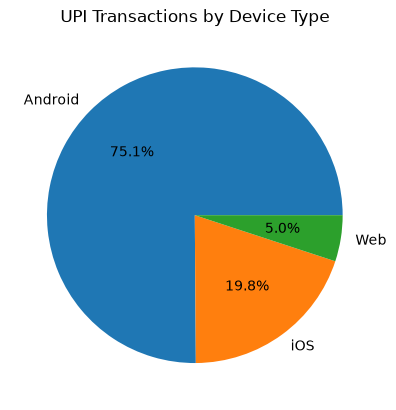

In [57]:
device_count = df["device_type"].value_counts()

plt.pie(
    device_count,
    labels=device_count.index,
    autopct="%1.1f%%"
)

plt.title("UPI Transactions by Device Type")
plt.show()

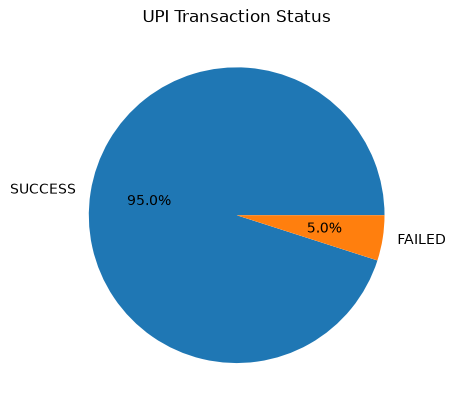

In [62]:
#Transaction Status — Pie Chart
status_count = df["transaction_status"].value_counts()

plt.pie(
    status_count,
    labels=status_count.index,
    autopct="%1.1f%%"
)

plt.title("UPI Transaction Status")

plt.show()

In [64]:
print(
    hour_analysis
    .sort_values("transaction_count", ascending=False)
    .head(5)
)

             transaction_count  total_value  average_amount
hour_of_day                                                
19                       21232     28223522     1329.291729
18                       20064     26297174     1310.664573
20                       18506     23822014     1287.258943
17                       18340     24514186     1336.651363
12                       17516     23406280     1336.279973


In [65]:
print(
    day_analysis
    .sort_values("transaction_count", ascending=False)
    .head(7)
)

             transaction_count  total_value  average_amount
day_of_week                                                
Monday                   36495     47882908     1312.040225
Sunday                   36003     47572544     1321.349443
Wednesday                35700     46815663     1311.363109
Tuesday                  35540     46846390     1318.131401
Friday                   35496     46332583     1305.290258
Thursday                 35432     46620985     1315.787565
Saturday                 35334     45867936     1298.124639


In [66]:
print(
    age_analysis
    .sort_values("transaction_count", ascending=False)
)

                  transaction_count  total_value  average_amount
sender_age_group                                                
26-35                         87432    115959771     1326.285239
36-45                         62873     89533745     1424.041242
18-25                         62345     74473936     1194.545449
46-55                         24841     33116261     1333.129141
56+                           12509     14855296     1187.568631


In [67]:
print(
    merchant_analysis
    .sort_values("transaction_count", ascending=False)
)

                   transaction_count  total_value  average_amount
merchant_category                                                
Grocery                        49966     58277893     1166.350979
Food                           37464     19919402      531.694480
Shopping                       29872     76863207     2573.085398
Fuel                           25063     38982575     1555.383434
Other                          24828     21073449      848.777550
Utilities                      22338     52742482     2361.110305
Transport                      20105      6192416      308.003780
Entertainment                  20103      8309080      413.325374
Healthcare                     12663      6874159      542.853905
Education                       7598     38704346     5094.017636


In [68]:
status_count = df["transaction_status"].value_counts()

status_percentage = df["transaction_status"].value_counts(
    normalize=True
) * 100

print(status_count)
print(status_percentage)

transaction_status
SUCCESS    237624
FAILED      12376
Name: count, dtype: int64
transaction_status
SUCCESS    95.0496
FAILED      4.9504
Name: proportion, dtype: float64


In [69]:
fraud_count = df["fraud_flag"].value_counts()

fraud_percentage = df["fraud_flag"].value_counts(
    normalize=True
) * 100

print(fraud_count)
print(fraud_percentage)

fraud_flag
0    249520
1       480
Name: count, dtype: int64
fraud_flag
0    99.808
1     0.192
Name: proportion, dtype: float64


In [70]:
print(
    fraud_by_merchant
    .sort_values("fraud_rate", ascending=False)
)

                   fraud_count  total_transactions  fraud_rate
merchant_category                                             
Transport                   43               20105    0.213877
Education                   16                7598    0.210582
Shopping                    62               29872    0.207552
Other                       50               24828    0.201386
Entertainment               40               20103    0.198975
Food                        73               37464    0.194854
Fuel                        48               25063    0.191517
Grocery                     94               49966    0.188128
Healthcare                  21               12663    0.165837
Utilities                   33               22338    0.147730
